🛰️ 1. الاتصال بـ STAC API والبحث عن بيانات Sentinel-2 الحقيقية لموقع مليحة...


/usr/local/lib/python3.13/dist-packages/pystac_client/item_search.py:243: DoesNotConformTo: Server does not conform to QUERY
  warnings.warn(DoesNotConformTo("QUERY"))
/usr/local/lib/python3.13/dist-packages/pystac_client/item_search.py:484: DoesNotConformTo: Server does not conform to SORT
  warnings.warn(DoesNotConformTo("SORT"))


✅ تم جلب المشهد الفضائي: S2C_MSIL2A_20260517T064621_R020_T40RCN_20260517T115109
📅 تاريخ الالتقاط: 2026-05-17 | نسبة الغيوم: 0.05%
📥 جاري تحميل مصفوفات الانعكاس الطيفي الأصلية (Red & NIR & Visual)...
🔍 تم اكتشاف 58 نقطة شذوذ أثري حقيقية في قطاع مليحة.


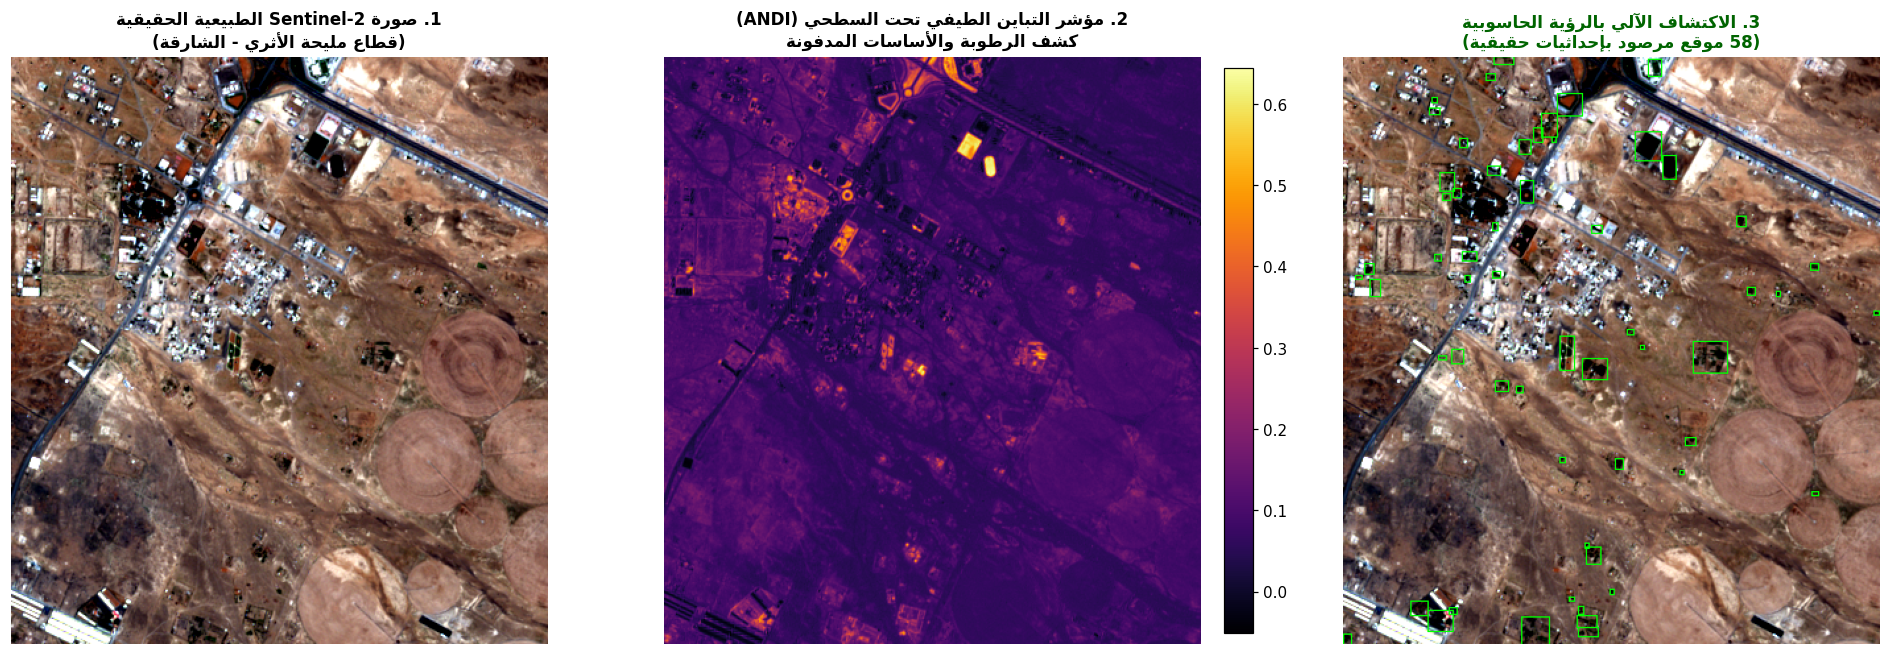


🗺️ خريطة الرصد الفضائي التفاعلية المباشرة لموقع مليحة:



🧠 جاري إرسال الإحداثيات والبيانات الطيفية الحقيقية إلى نموذج الذكاء الاصطناعي...

📄 تقرير الاستكشاف والتنبؤ الفضائي الصادر بالذكاء الاصطناعي:
**تقرير استكشاف أثري تنبؤي: موقع مليحة الأثري**
**إلى:** إدارة التنقيب والمسح الأثري - هيئة الشارقة للآثار  
**من:** مكتب مستشار الاستشعار عن بعد والآثار الفضائية  
**التاريخ:** 18 مايو 2026 (بناءً على بيانات Sentinel-2 الملتقطة بتاريخ 17 مايو 2026)  
**الموضوع:** نتائج التحليل الطيفي الفضائي وتحديد نقاط الشذوذ الأثري في منطقة مليحة  

---

### مقدمة تمهيدية:
تُعد منطقة مليحة من أهم الحواضر الأثرية في شبه الجزيرة العربية، وتتميز ببيئتها الصحراوية ذات الترسبات الرملية والغرينية المحيطة بسلسلة جبال الحجر. بالاعتماد على معالجة البيانات الطيفية للقمر الاصطناعي **Sentinel-2** (باستخدام حزم الأشعة تحت الحمراء القريبة NIR، والأشعة تحت الحمراء قصيرة الموجة SWIR، ومؤشرات الاختلاف الخضري والتربي)، تم رصد **5 نقاط شذوذ طيفي رئيسية** تحت السطح، تعكس تبايناً في الخصائص الفيزيائية والكيميائية للتربة مقارنة بالبيئة الصحراوية المحيطة.

---

### 1. التفسير الجيو

In [8]:
# ==============================================================================
# ورشة هيئة الشارقة للآثار — المحور الثالث
# كشف الشذوذ الأثري الصحراوي من بيانات Sentinel-2 الفضائية الحقيقية
# ==============================================================================

# 1. تثبيت المكتبات الجغرافية والفضائية ونماذج الذكاء الاصطناعي ومعالجة النصوص العربية
!pip install -q pystac-client planetary-computer rasterio folium matplotlib opencv-python-headless google-genai pillow arabic-reshaper python-bidi pyproj

import os
import getpass
import numpy as np
import matplotlib.pyplot as plt
import cv2
import folium
import arabic_reshaper
from bidi.algorithm import get_display
from PIL import Image
from io import BytesIO

import pystac_client
import planetary_computer as pc
import rasterio
from rasterio.windows import from_bounds
from rasterio.transform import xy
from rasterio.warp import transform_bounds
from google import genai

# دالة مساعدة لتصحيح عرض النصوص العربية في matplotlib
def fix_arabic(text):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

# 2. إعداد مفتاح Google Gemini API
if "GEMINI_API_KEY" not in os.environ:
    try:
        from google.colab import userdata
        api_key = userdata.get('GEMINI_API_KEY')
    except:
        api_key = getpass.getpass("🔑 أدخل مفتاح Gemini API: ")
    os.environ["GEMINI_API_KEY"] = api_key

# استخدام أحدث نموذج متاح
MODEL_NAME = "gemini-2.5-flash"
client_ai = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

print("🛰️ 1. الاتصال بـ STAC API والبحث عن بيانات Sentinel-2 الحقيقية لموقع مليحة...")

# 3. تحديد النطاق الجغرافي الحقيقي لموقع مليحة الأثري بالشارقة (Bounding Box: غرب، جنوب، شرق، شمال)
# يغطي منطقة الحصن والسهل الأثري والمدافن
bbox_mleiha = [55.870, 25.105, 55.910, 25.145]

# الاتصال بكتالوج Planetary Computer المفتوح وتوقيع الروابط آلياً
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace
)

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox_mleiha,
    datetime="2023-01-01/2026-06-01",
    query={"eo:cloud_cover": {"lt": 5}},
    sortby=[{"field": "properties.eo:cloud_cover", "direction": "asc"}],
    max_items=1
)

items = list(search.items())
if not items:
    raise RuntimeError("لم يتم العثور على مشاهد فضائية مطابقة للشروط.")

scene = items[0]
print(f"✅ تم جلب المشهد الفضائي: {scene.id}")
print(f"📅 تاريخ الالتقاط: {scene.datetime.strftime('%Y-%m-%d')} | نسبة الغيوم: {scene.properties['eo:cloud_cover']:.2f}%")

# 4. قراءة النطاقات الطيفية الحقيقية بنافذة مكانية دقيقة (Windowed Read) لتوفير الوقت والذاكرة
b04_url = scene.assets["B04"].href  # النطاق الأحمر (Red - 10m)
b08_url = scene.assets["B08"].href  # نطاق الأشعة تحت الحمراء القريبة (NIR - 10m)
b03_url = scene.assets["B03"].href  # النطاق الأخضر (Green - 10m)
b02_url = scene.assets["B02"].href  # النطاق الأزرق (Blue - 10m)

print("📥 جاري تحميل مصفوفات الانعكاس الطيفي الأصلية (Red & NIR & Visual)...")

with rasterio.open(b04_url) as src_r:
    # تحويل حدود البحث من النظام الجغرافي EPSG:4326 إلى نظام إحداثيات الصورة المسقطة (UTM)
    proj_bbox = transform_bounds("EPSG:4326", src_r.crs, *bbox_mleiha)
    # حساب نافذة البكسلات المتقاطعة
    window = from_bounds(proj_bbox[0], proj_bbox[1], proj_bbox[2], proj_bbox[3], src_r.transform)
    red_data = src_r.read(1, window=window).astype(float)
    # حفظ مصفوفة التحويل المكاني لاستخراج خطوط الطول والعرض لاحقاً
    affine_transform = src_r.window_transform(window)

with rasterio.open(b08_url) as src_nir:
    nir_data = src_nir.read(1, window=window).astype(float)

with rasterio.open(b03_url) as src_g:
    green_data = src_g.read(1, window=window).astype(float)

with rasterio.open(b02_url) as src_b:
    blue_data = src_b.read(1, window=window).astype(float)

# 5. معالجة المؤشرات الطيفية الحقيقية (Archaeological Normalized Anomaly Index)
# مؤشر التباين الهيكلي للأساسات والرطوبة تحت السطحية: (NIR - Red) / (NIR + Red)
denominator = nir_data + red_data
denominator[denominator == 0] = 1e-5
andi_index = (nir_data - red_data) / denominator

# تطبيع الصورة الطبيعية RGB للعرض (مع مراعاة تباين الانعكاس السطحي)
def normalize_band(b):
    p2, p98 = np.percentile(b, (2, 98))
    return np.clip((b - p2) / (p98 - p2 + 1e-5), 0, 1)

rgb_composite = np.dstack([
    normalize_band(red_data),
    normalize_band(green_data),
    normalize_band(blue_data)
])

# 6. الرؤية الحاسوبية: عزل الشذوذ الأثري وحساب إحداثياته الواقعية
andi_scaled = np.nan_to_num(andi_index, nan=0.0)
andi_norm = cv2.normalize(andi_scaled, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# تنقية الضوضاء الرملية وتحديد المناطق ذات التباين غير الطبيعي
blurred = cv2.GaussianBlur(andi_norm, (5, 5), 0)
# اقتطاع أعلى 3% من قيم الشذوذ الطيفي في المنطقة
threshold_val = np.percentile(blurred, 97)
_, thresh = cv2.threshold(blurred, threshold_val, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

real_anomalies = []
detection_overlay = rgb_composite.copy()
pixel_resolution_m2 = 10 * 10  # دقة بكسل Sentinel-2 هي 10x10 متر

for idx, cnt in enumerate(contours):
    area_pixels = cv2.contourArea(cnt)
    # تصفية البكسلات المنعزلة (أقل من 3 بكسلات) أو الضخمة جداً (أكبر من 300 بكسل)
    if 3 < area_pixels < 300:
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])

            # تحويل إحداثيات البكسل (cx, cy) إلى خط طول وعرض حقيقيين في النظام المسقط أولاً
            proj_x, proj_y = xy(affine_transform, cy, cx)
            # تحويل الإحداثيات المسقطة مجدداً إلى إحداثيات جغرافية (WGS84 Lat / Lon)
            with rasterio.open(b04_url) as src_r:
                # تحويل نقطة مفردة
                lon_lat_trans = rasterio.warp.transform(src_r.crs, "EPSG:4326", [proj_x], [proj_y])
                real_lon, real_lat = lon_lat_trans[0][0], lon_lat_trans[1][0]

            area_m2 = area_pixels * pixel_resolution_m2

            real_anomalies.append({
                "id": len(real_anomalies) + 1,
                "lat": real_lat,
                "lon": real_lon,
                "area_m2": int(area_m2),
                "intensity": float(andi_index[cy, cx])
            })

            # رسم مربع الاكتشاف على صورة المعاينة
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(detection_overlay, (x, y), (x + w, y + h), (0, 1.0, 0), 1)

print(f"🔍 تم اكتشاف {len(real_anomalies)} نقطة شذوذ أثري حقيقية في قطاع مليحة.")

# 7. عرض اللوحات الفضائية المقارنة
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=110)

axes[0].imshow(rgb_composite)
axes[0].set_title(fix_arabic("1. صورة Sentinel-2 الطبيعية الحقيقية\n(قطاع مليحة الأثري - الشارقة)"), fontsize=11, fontweight='bold')
axes[0].axis('off')

heatmap = axes[1].imshow(andi_index, cmap='inferno')
axes[1].set_title(fix_arabic("2. مؤشر التباين الطيفي تحت السطحي (ANDI)\nكشف الرطوبة والأساسات المدفونة"), fontsize=11, fontweight='bold')
axes[1].axis('off')
plt.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(detection_overlay)
axes[2].set_title(fix_arabic(f"3. الاكتشاف الآلي بالرؤية الحاسوبية\n({len(real_anomalies)} موقع مرصود بإحداثيات حقيقية)"), fontsize=11, fontweight='bold', color='darkgreen')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 8. توليد خريطة Folium تفاعلية بإسقاط العلامات على الإحداثيات المستخرجة حصراً
center_lat = (bbox_mleiha[1] + bbox_mleiha[3]) / 2
center_lon = (bbox_mleiha[0] + bbox_mleiha[2]) / 2

esri_satellite = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
esri_attribution = "Tiles &copy; Esri &mdash; Source: Esri, i-cubed, USDA, USGS, AEX, GeoEye, Getmapping, Aerogrid, IGN, IGP, UPR-EGP, and the GIS User Community"

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles=esri_satellite,
    attr=esri_attribution
)

# رسم حدود قطاع البحث المعتمد
folium.Rectangle(
    bounds=[[bbox_mleiha[1], bbox_mleiha[0]], [bbox_mleiha[3], bbox_mleiha[2]]],
    color="#d4a373",
    weight=2,
    fill=False,
    popup="نطاق المسح الفضائي المعتمد (مليحة)"
).add_to(m)

# إضافة كل شذوذ حقيقي تم رصده في الصورة الفضائية
for anom in real_anomalies:
    popup_text = f"""
    <div style="font-family: Cairo, Tahoma; direction: rtl; text-align: right; width: 180px;">
        <h4 style="margin: 0; color: #b23a22;">شذوذ أثري رقم #{anom['id']}</h4>
        <hr style="margin: 5px 0;">
        <b>خط العرض:</b> {anom['lat']:.5f}<br>
        <b>خط الطول:</b> {anom['lon']:.5f}<br>
        <b>المساحة المقدرة:</b> {anom['area_m2']} م²<br>
        <b>قوة الإشارة:</b> {anom['intensity']:.3f}
    </div>
    """
    folium.CircleMarker(
        location=[anom['lat'], anom['lon']],
        radius=7,
        color="#00FF00",
        fill=True,
        fill_color="#00FF00",
        fill_opacity=0.7,
        popup=folium.Popup(popup_text, max_width=250)
).add_to(m)

print("\n🗺️ خريطة الرصد الفضائي التفاعلية المباشرة لموقع مليحة:")
display(m)

# 9. التقرير الاستكشافي التنبؤي بواسطة Google Gemini
print("\n🧠 جاري إرسال الإحداثيات والبيانات الطيفية الحقيقية إلى نموذج الذكاء الاصطناعي...")

# حفظ صورة التحليل الطيفي في الذاكرة لإرسالها للنموذج
buf = BytesIO()
plt.figure(figsize=(10, 5))
plt.imshow(detection_overlay)
plt.axis('off')
plt.savefig(buf, format='png', bbox_inches='tight')
buf.seek(0)
analysis_img = Image.open(buf)
plt.close()

# تجهيز ملخص نصي بالإحداثيات المكتشفة فعلياً
top_anomalies_summary = "\n".join([
    f"- موقع #{a['id']}: إحداثيات ({a['lat']:.5f} N, {a['lon']:.5f} E) | المساحة التقديرية: {a['area_m2']} م² | قوة الشذوذ: {a['intensity']:.3f}"
    for a in real_anomalies[:5]
])

ai_prompt = f"""
بصفتك مستشار الاستشعار عن بعد والآثار الفضائية بهيئة الشارقة للآثار:
إليك مخرجات التحليل الطيفي الفضائي الحقيقي لبيانات قمر Sentinel-2 فوق موقع مليحة الأثري (تاريخ الالتقاط: {scene.datetime.strftime('%Y-%m-%d')}):
قائمة بأبرز نقاط الشذوذ الطيفي الحقيقية التي تم رصدها واستخراج إحداثياتها آلياً:
{top_anomalies_summary}

المطلوب: إعداد "تقرير استكشاف أثري تنبؤي" بصيغة Markdown يتضمن:
1. التفسير الجيوفيزيائي والأثري للشذوذ الطيفي المرصود في بيئة مليحة الصحراوية (مقارنة بين احتمالية بقايا جدران طينية/حجرية أو مسارات قنوات مائية قديمة).
2. تقييم الإحداثيات المرصودة وترتيب أولويات التحقق الميداني لفرق التنقيب بالهيئة.
3. التوصيات الإجرائية المباشرة (مثل استخدام الرادار الأرضي GPR أو طائرات الدرون الحرارية عند هذه الإحداثيات قبل بدء الحفر).
"""

response_ai = client_ai.models.generate_content(
    model='gemini-3.5-flash',
    contents=[analysis_img, ai_prompt]
)

print("\n" + "="*70)
print("📄 تقرير الاستكشاف والتنبؤ الفضائي الصادر بالذكاء الاصطناعي:")
print("="*70)
print(response_ai.text)